In [1]:
# IMPORTING LIBRARIES 
# NUMERICAL OPERATIONS

import pandas as pd
import numpy as np

# DATA VISUALIZATION 

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
# LOAD DATASET
df = pd.read_csv(r'\Users\HP\OneDrive - Loughborough University\Advanced programming and Data Visualisation\archive (5)\inventory.csv')

In [3]:
# DISPLAY DATA

display(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer



Dataset Shape:
(73100, 15)

Column Names:
Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast',
       'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion',
       'Competitor Pricing', 'Seasonality'],
      dtype='object')


In [4]:
# RENAME COLUMNS 

df.columns = [
    'Date',
    'Store_ID',
    'Product_ID',
    'Category',
    'Region',
    'Inventory_Level',
    'Units_Sold',
    'Units_Ordered',
    'Demand_Forecast',
    'Price',
    'Discount',
    'Weather_Condition',
    'Holiday_Promotion',
    'Competitor_Pricing',
    'Seasonality'
]


In [5]:
# # DATA PREPROCESSING 
df.nunique()

Date                    731
Store_ID                  5
Product_ID               20
Category                  5
Region                    4
Inventory_Level         451
Units_Sold              498
Units_Ordered           181
Demand_Forecast       31608
Price                  8999
Discount                  5
Weather_Condition         4
Holiday_Promotion         2
Competitor_Pricing     9751
Seasonality               4
dtype: int64

In [6]:
df.duplicated().sum() # check for duplicates 

np.int64(0)

In [7]:
df.isna().sum() # COUNT MISSING VALUES IN EACH COLUMNS 

Date                  0
Store_ID              0
Product_ID            0
Category              0
Region                0
Inventory_Level       0
Units_Sold            0
Units_Ordered         0
Demand_Forecast       0
Price                 0
Discount              0
Weather_Condition     0
Holiday_Promotion     0
Competitor_Pricing    0
Seasonality           0
dtype: int64

In [8]:
# Convert Date Column to date values 

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

In [9]:
df['Date'].min(), df['Date'].max()

(Timestamp('2022-01-01 00:00:00'), Timestamp('2024-01-01 00:00:00'))

In [10]:
#  LABEL ENCODING CONVERT TEXT TO INTEGER

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Store_ID'] = le.fit_transform(df['Store_ID'])

df['Product_ID'] = le.fit_transform(df['Product_ID'])

In [11]:
# ONE HOT ENCODING 

df = pd.get_dummies(
    df,
    columns=[
        'Category',
        'Region',
        'Weather_Condition',
        'Seasonality'
    ],
    drop_first=True,
    dtype=int
)

In [12]:
df.head()

,Date,Store_ID,Product_ID,Inventory_Level,Units_Sold,Units_Ordered,Demand_Forecast,Price,Discount,Holiday_Promotion,...,Category_Toys,Region_North,Region_South,Region_West,Weather_Condition_Rainy,Weather_Condition_Snowy,Weather_Condition_Sunny,Seasonality_Spring,Seasonality_Summer,Seasonality_Winter
0,2022-01-01,0,0,231,127,55,135.47,33.50,20,0,...,0,1,0,0,1,0,0,0,0,0
1,2022-01-01,0,1,204,150,66,144.04,63.01,20,0,...,1,0,1,0,0,0,1,0,0,0
2,2022-01-01,0,2,102,65,51,74.02,27.99,10,1,...,1,0,0,1,0,0,1,0,1,0
3,2022-01-01,0,3,469,61,164,62.18,32.72,10,1,...,1,1,0,0,0,0,0,0,0,0
4,2022-01-01,0,4,166,14,135,9.26,73.64,0,0,...,0,0,0,0,0,0,1,0,1,0


In [13]:
# BASIC EDA

print("\nDataset Info:\n")
print(df.info())

print("\nStatistical Summary:\n")
display(df.describe())


Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Date                     73100 non-null  datetime64[ns]
 1   Store_ID                 73100 non-null  int64         
 2   Product_ID               73100 non-null  int64         
 3   Inventory_Level          73100 non-null  int64         
 4   Units_Sold               73100 non-null  int64         
 5   Units_Ordered            73100 non-null  int64         
 6   Demand_Forecast          73100 non-null  float64       
 7   Price                    73100 non-null  float64       
 8   Discount                 73100 non-null  int64         
 9   Holiday_Promotion        73100 non-null  int64         
 10  Competitor_Pricing       73100 non-null  float64       
 11  Category_Electronics     73100 non-null  int64         
 12  Category_Furnitu

,Date,Store_ID,Product_ID,Inventory_Level,Units_Sold,Units_Ordered,Demand_Forecast,Price,Discount,Holiday_Promotion,...,Category_Toys,Region_North,Region_South,Region_West,Weather_Condition_Rainy,Weather_Condition_Snowy,Weather_Condition_Sunny,Seasonality_Spring,Seasonality_Summer,Seasonality_Winter
count,73100,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,...,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,2022-12-31 23:59:59.999999744,2.000000,9.500000,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,...,0.200315,0.249357,0.250301,0.249330,0.250041,0.249959,0.250205,0.250575,0.250410,0.250137
min,2022-01-01 00:00:00,0.000000,0.000000,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2022-07-02 00:00:00,1.000000,4.750000,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2023-01-01 00:00:00,2.000000,9.500000,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2023-07-03 00:00:00,3.000000,14.250000,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,...,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000
max,2024-01-01 00:00:00,4.000000,19.000000,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
std,NaN,1.414223,5.766321,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,...,0.400239,0.432644,0.433189,0.432628,0.433039,0.432992,0.433134,0.433347,0.433252,0.433095


In [14]:
# outlier detection

numerical_cols = [
    'Inventory_Level',
    'Units_Sold',
    'Units_Ordered',
    'Price',
    'Competitor_Pricing'
]



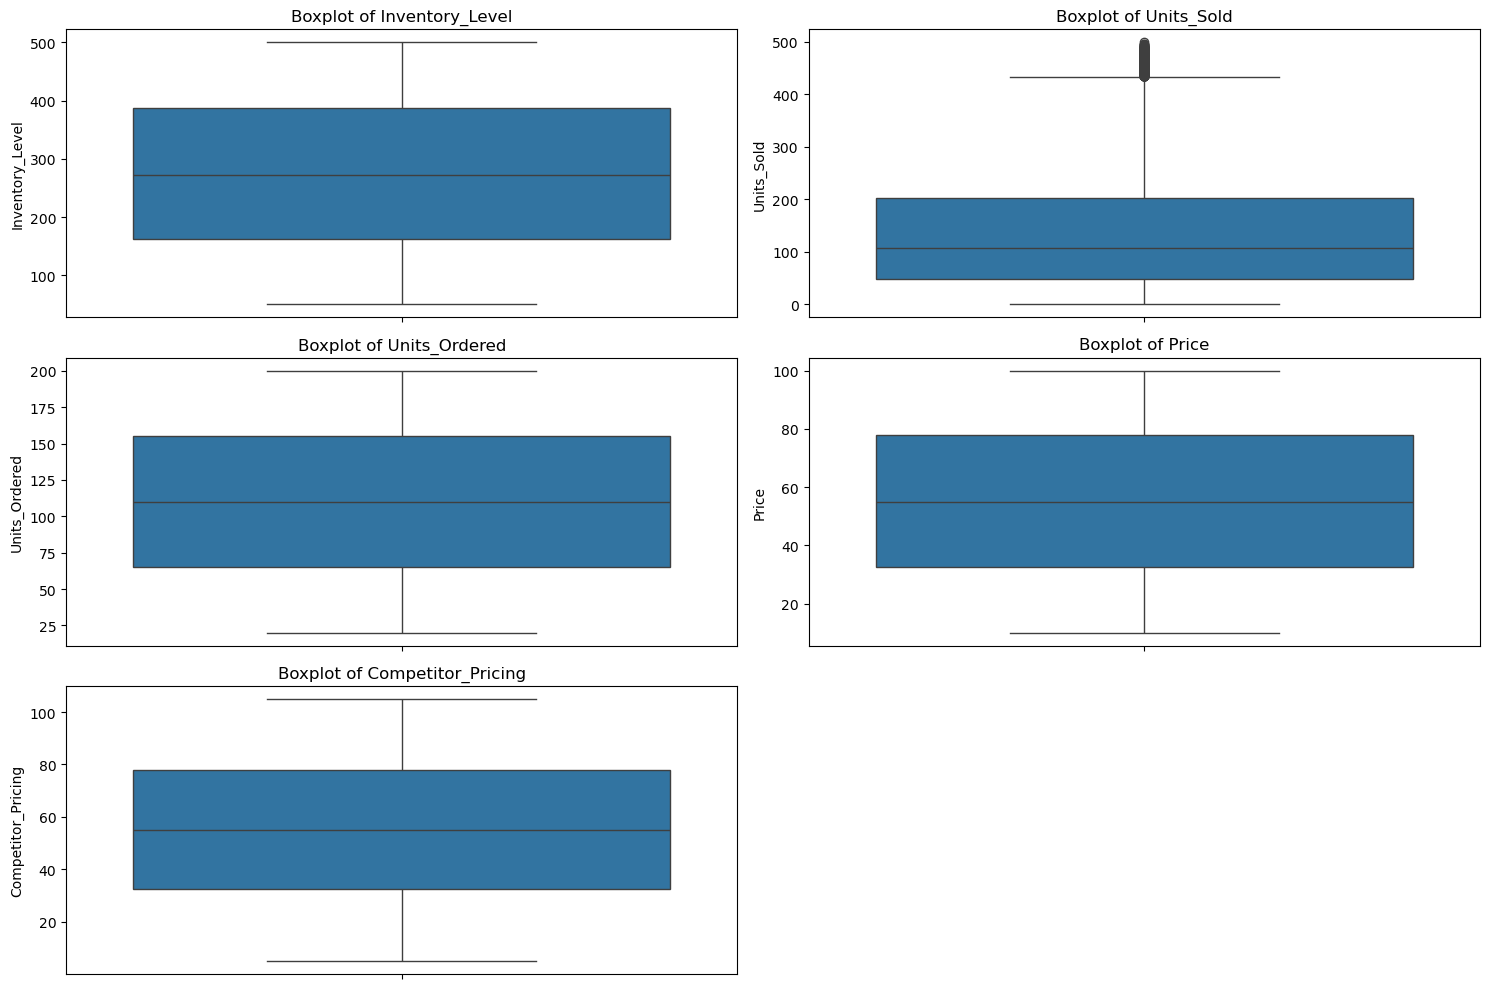

In [15]:
plt.figure(figsize=(15,10))

for i, col in enumerate(numerical_cols):

    plt.subplot(3,2,i+1)

    sns.boxplot(y=df[col])

    plt.title(f'Boxplot of {col}')

plt.tight_layout()

plt.show()

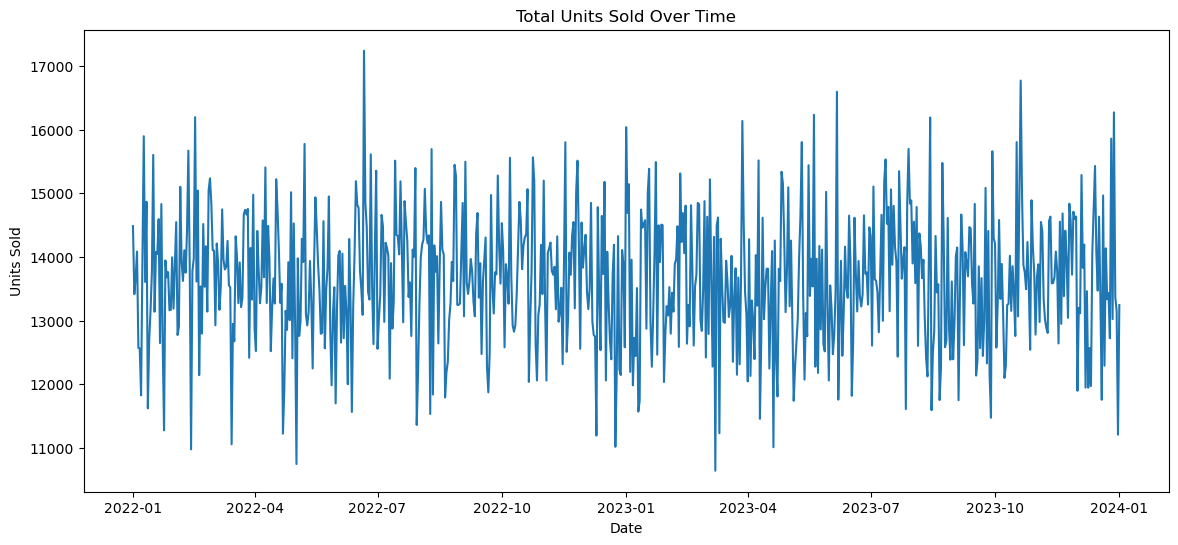

In [16]:
# linegraph (SALES TREND OVER TIME)

sales_trend = df.groupby('Date')['Units_Sold'].sum()

plt.figure(figsize=(14,6))

plt.plot(sales_trend)

plt.title("Total Units Sold Over Time")

plt.xlabel("Date")

plt.ylabel("Units Sold")

plt.show()


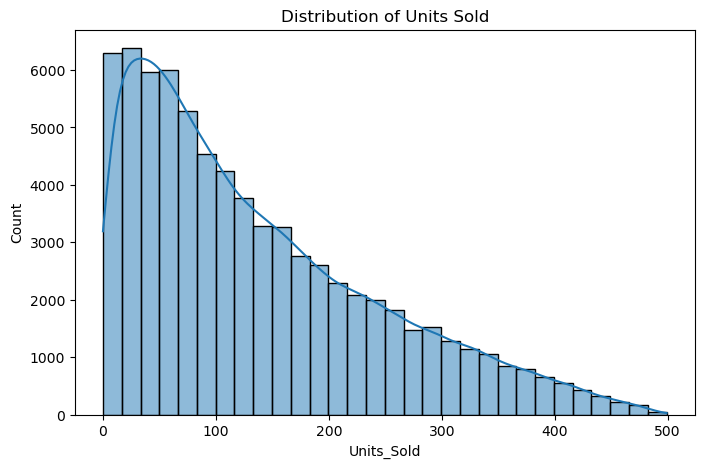

In [17]:
# DISTRIBUTION OF UNITS SOLD USING HISTOGRAM 

plt.figure(figsize=(8,5))

sns.histplot(df['Units_Sold'],
             bins=30,
             kde=True) 

plt.title("Distribution of Units Sold")

plt.show()

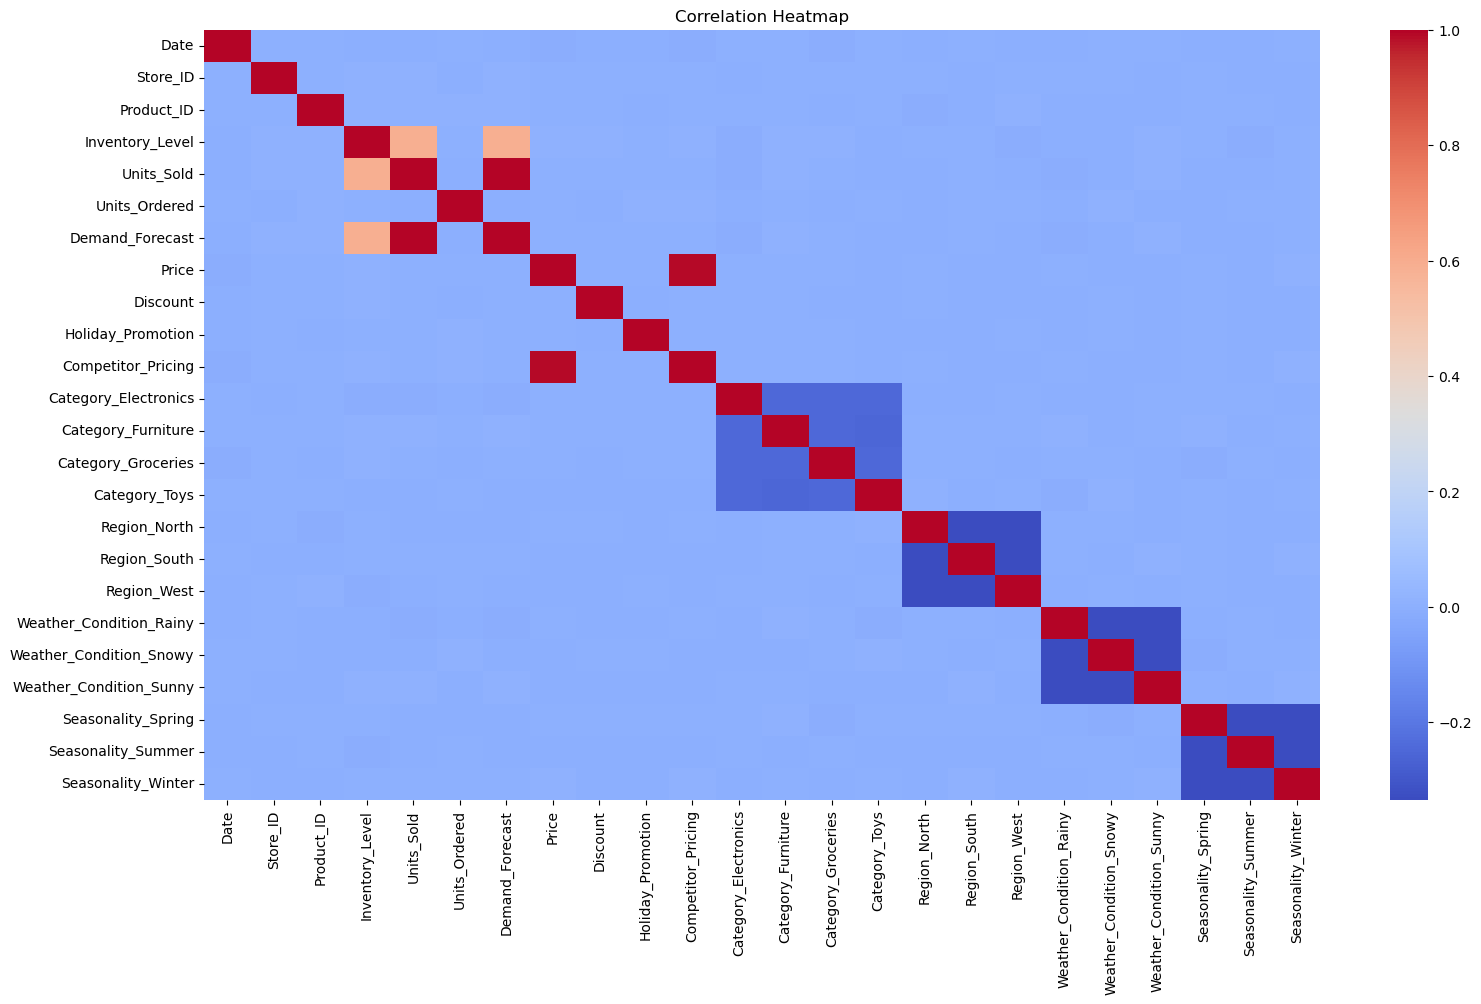

In [18]:
# CORRELATION HEATMAP

plt.figure(figsize=(18,10))

sns.heatmap(df.corr(),
            cmap='coolwarm',
            annot=False)

plt.title("Correlation Heatmap")

plt.show()

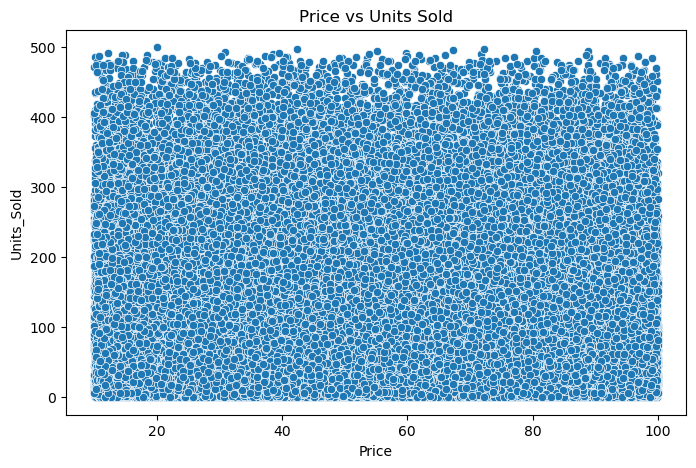

In [19]:
# SCATTER PLOT (PRICE VS UNITS SOLD)

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['Price'],
    y=df['Units_Sold']
)

plt.title("Price vs Units Sold")

plt.show()


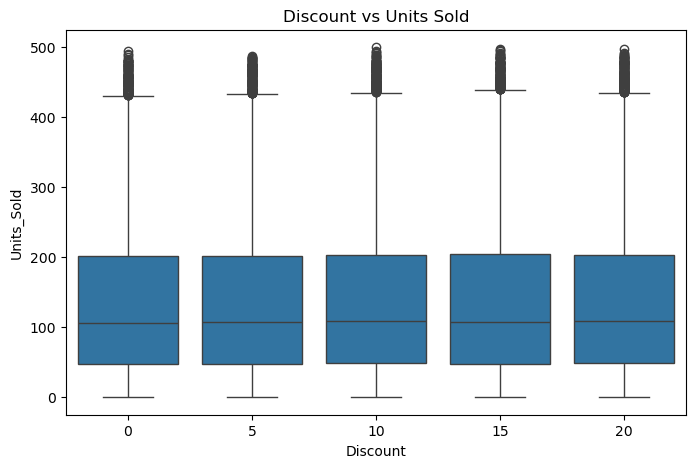

In [20]:
# BOXPLOT (DISCOUNT VS UNITS SOLD)

plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['Discount'],
    y=df['Units_Sold']
)

plt.title("Discount vs Units Sold")

plt.show()

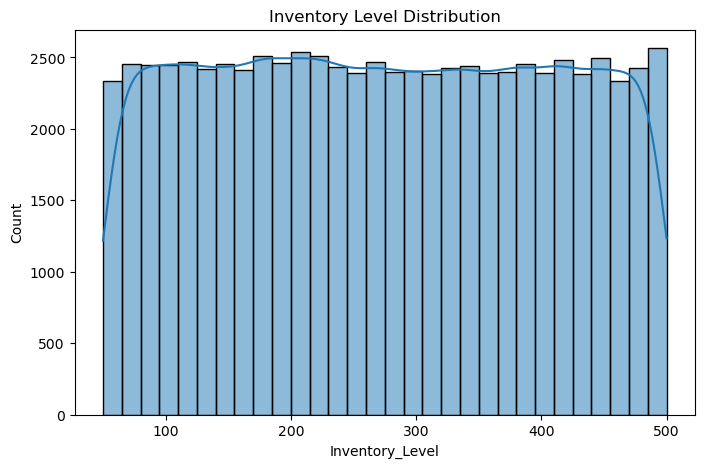

In [21]:
# INVENTORY DISTRIBUTION

plt.figure(figsize=(8,5))

sns.histplot(
    df['Inventory_Level'],
    bins=30,
    kde=True
)

plt.title("Inventory Level Distribution")

plt.show()

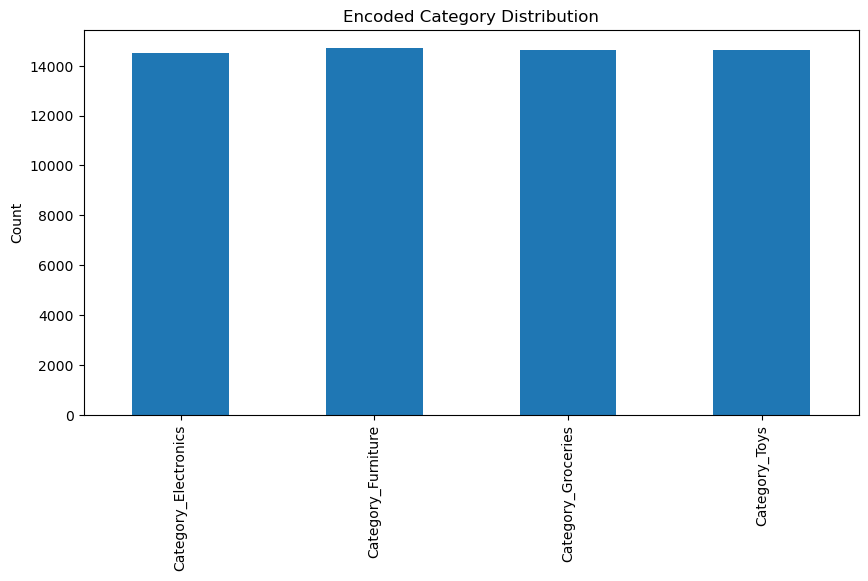

In [22]:
# BAR CHART Category wise sales 
category_cols = [col for col in df.columns if 'Category_' in col]

category_sales = df[category_cols].sum()

plt.figure(figsize=(10,5))

category_sales.plot(kind='bar')

plt.title("Encoded Category Distribution")
plt.ylabel("Count")

plt.show()

In [23]:
# feature importance style correlation ( USING PANDAS LIBRARY )

corr_target = df.corr()['Units_Sold'].sort_values(ascending=False)

print("\nCorrelation with Units_Sold:\n")
print(corr_target)


Correlation with Units_Sold:

Units_Sold                 1.000000
Demand_Forecast            0.996853
Inventory_Level            0.589995
Weather_Condition_Sunny    0.008294
Product_ID                 0.007005
Category_Furniture         0.005991
Store_ID                   0.005363
Region_South               0.003161
Discount                   0.002576
Category_Groceries         0.002071
Seasonality_Winter         0.001940
Competitor_Pricing         0.001259
Price                      0.001082
Holiday_Promotion         -0.000374
Region_North              -0.000730
Units_Ordered             -0.000930
Date                      -0.002093
Category_Toys             -0.002438
Weather_Condition_Snowy   -0.002933
Seasonality_Spring        -0.003387
Region_West               -0.004545
Seasonality_Summer        -0.005501
Category_Electronics      -0.006666
Weather_Condition_Rainy   -0.006917
Name: Units_Sold, dtype: float64


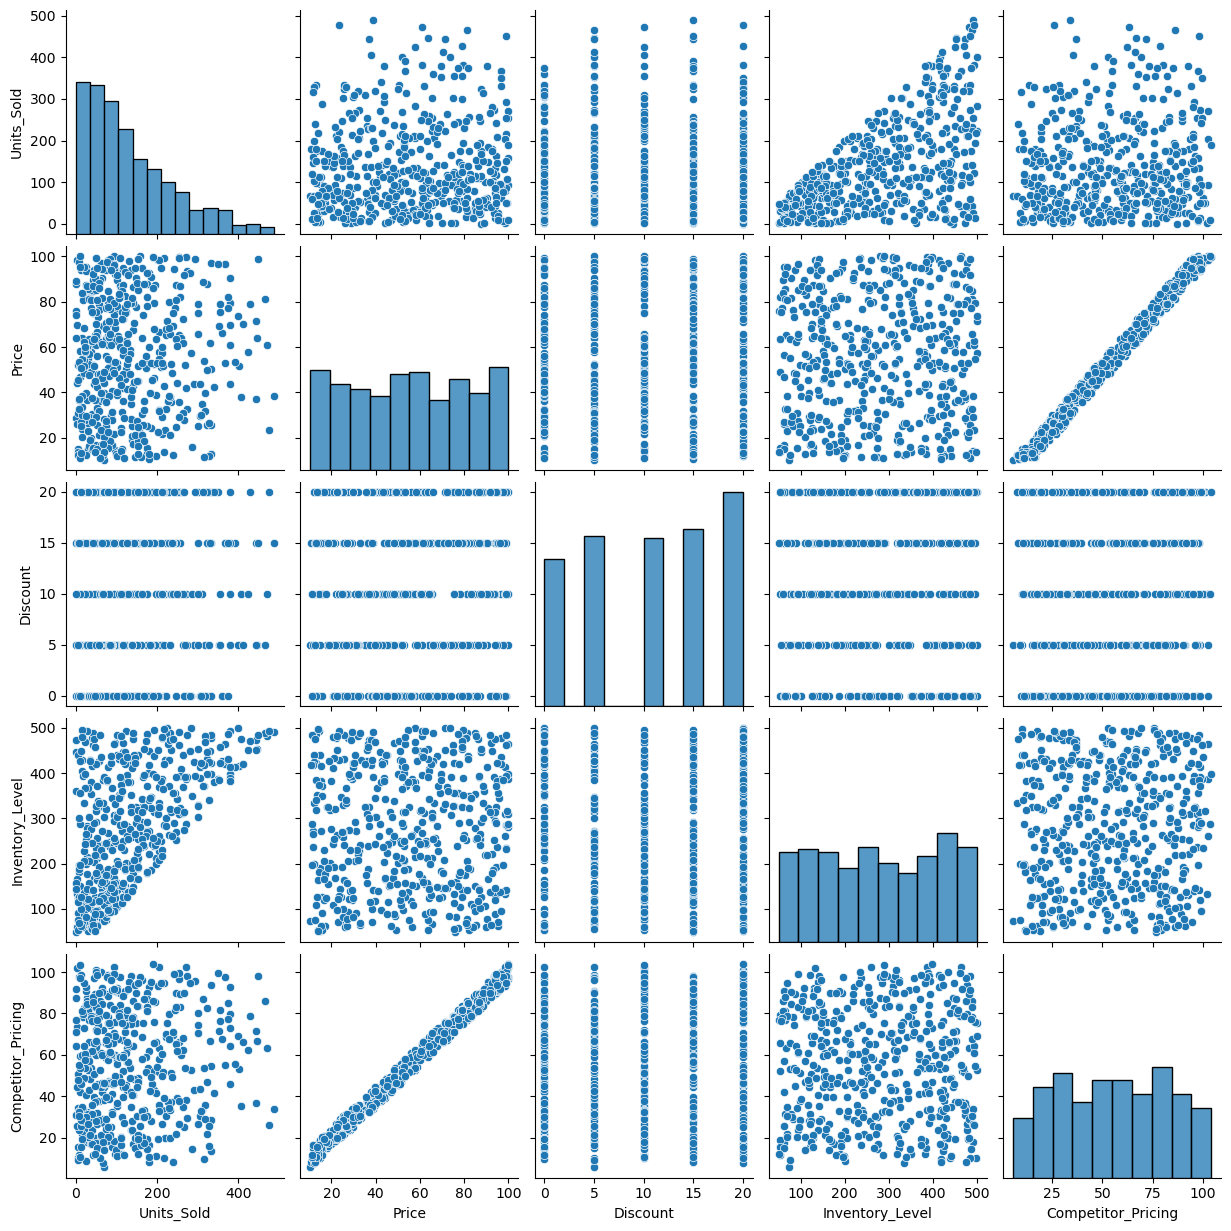

In [24]:
# Pair plot 

sample_df = df[['Units_Sold',
                'Price',
                'Discount',
                'Inventory_Level',
                'Competitor_Pricing']].sample(500)

sns.pairplot(sample_df)

plt.show()

In [25]:
# CREATED CLASSIFICATION TARGET

# 1 = High Demand
# 0 = Low Demand

df['High_Demand'] = (
    df['Units_Sold'] > 150
).astype(int)


In [26]:
# FEATURES & TARGET

X = df.drop([
    'Units_Sold',
    'Date',
    'Demand_Forecast',
    'High_Demand'
], axis=1)

y = df['High_Demand']

In [27]:
# TRAIN TEST SPLIT

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [28]:
# FEATURE SCALING

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [29]:
# IMPORT MODELS

from sklearn.linear_model import (
    LogisticRegression,
)

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)


In [30]:
# LOGISTIC REGRESSION

log_model = LogisticRegression(
    max_iter=500,
    solver='lbfgs'
)

log_model.fit(X_train_scaled, y_train)

pred_log = log_model.predict(X_test_scaled)

In [31]:
# RANDOM FOREST CLASSIFIER

rf_model = RandomForestClassifier(
    n_estimators=100
)

rf_model.fit(X_train, y_train)

pred_rf = rf_model.predict(X_test)

In [32]:
# GRADIENT BOOSTING CLASSIFIER

gb_model = GradientBoostingClassifier()

gb_model.fit(X_train, y_train)

pred_gb = gb_model.predict(X_test)



In [33]:
# STACKING ENSEMBLE 

estimators = [
    ('rf', RandomForestClassifier(n_estimators=100)),
    ('gb', GradientBoostingClassifier())
]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)

stack_model.fit(X_train, y_train)

pred_stack = stack_model.predict(X_test)

In [34]:
# ACCURACY SCORES

from sklearn.metrics import accuracy_score

print("\nMODEL ACCURACY COMPARISON\n")

print("Logistic Regression:",
      accuracy_score(y_test, pred_log))

print("Random Forest:",
      accuracy_score(y_test, pred_rf))

print("Gradient Boosting:",
      accuracy_score(y_test, pred_gb))

print("Stacking Ensemble:",
      accuracy_score(y_test, pred_stack))


MODEL ACCURACY COMPARISON

Logistic Regression: 0.7216142270861833
Random Forest: 0.7154582763337893
Gradient Boosting: 0.7268809849521204
Stacking Ensemble: 0.7253761969904241


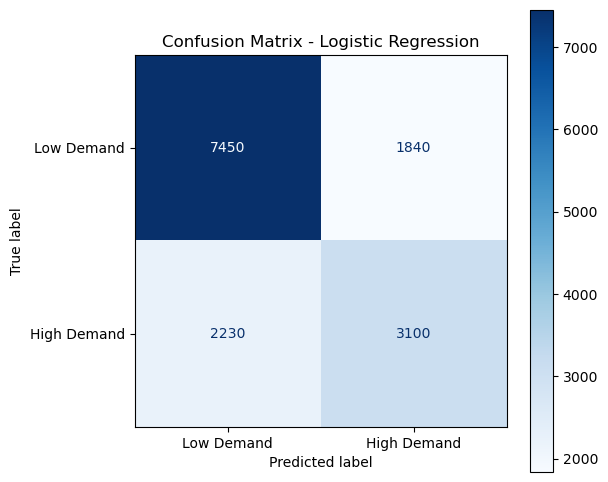

In [35]:
# CONFUSION MATRIX

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

cm = confusion_matrix(y_test, pred_log)

fig, ax = plt.subplots(figsize=(6,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        'Low Demand',
        'High Demand'
    ]
)

disp.plot(ax=ax, cmap='Blues')

plt.title(
    "Confusion Matrix - Logistic Regression"
)

plt.show()



In [36]:
# CLASSIFICATION REPORT

from sklearn.metrics import classification_report

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        pred_log
    )
)



Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.80      0.79      9290
           1       0.63      0.58      0.60      5330

    accuracy                           0.72     14620
   macro avg       0.70      0.69      0.69     14620
weighted avg       0.72      0.72      0.72     14620



In [37]:
# ROC CURVE & AUC SCORE

from sklearn.metrics import roc_curve, auc

In [38]:
# PREDICT PROBABILITIES

log_probs = log_model.predict_proba(X_test_scaled)[:,1]

rf_probs = rf_model.predict_proba(X_test)[:,1]

gb_probs = gb_model.predict_proba(X_test)[:,1]

stack_probs = stack_model.predict_proba(X_test)[:,1]

In [39]:
# ROC VALUES

from sklearn.metrics import roc_curve, auc

fpr_log, tpr_log, _ = roc_curve(y_test, log_probs)

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)

fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_probs)

fpr_stack, tpr_stack, _ = roc_curve(y_test, stack_probs)


In [40]:
# PRINT ROC VALUES

print("\nLOGISTIC REGRESSION ROC VALUES\n")
print("FPR:", fpr_log[:10])
print("TPR:", tpr_log[:10])

print("\nRANDOM FOREST ROC VALUES\n")
print("FPR:", fpr_rf[:10])
print("TPR:", tpr_rf[:10])

print("\nGRADIENT BOOSTING ROC VALUES\n")
print("FPR:", fpr_gb[:10])
print("TPR:", tpr_gb[:10])

print("\nSTACKING ENSEMBLE ROC VALUES\n")
print("FPR:", fpr_stack[:10])
print("TPR:", tpr_stack[:10])


LOGISTIC REGRESSION ROC VALUES

FPR: [0.         0.         0.         0.00043057 0.00043057 0.00053821
 0.00053821 0.0007535  0.0007535  0.00086114]
TPR: [0.         0.00018762 0.00056285 0.00056285 0.00075047 0.00075047
 0.00093809 0.00093809 0.00168856 0.00168856]

RANDOM FOREST ROC VALUES

FPR: [0.         0.00010764 0.00010764 0.00032293 0.00107643 0.00161464
 0.00236814 0.00365985 0.0050592  0.00710441]
TPR: [0.         0.00037523 0.00056285 0.00075047 0.00187617 0.00318949
 0.00506567 0.0097561  0.01294559 0.02045028]

GRADIENT BOOSTING ROC VALUES

FPR: [0.         0.         0.00053821 0.00053821 0.0007535  0.0007535
 0.00086114 0.00086114 0.00096878 0.00096878]
TPR: [0.         0.00018762 0.00018762 0.00056285 0.00056285 0.00131332
 0.00131332 0.00337711 0.00337711 0.00356473]

STACKING ENSEMBLE ROC VALUES

FPR: [0.         0.         0.00021529 0.00021529 0.00032293 0.00032293
 0.00053821 0.00053821 0.00064586 0.00064586]
TPR: [0.         0.00018762 0.00018762 0.00037523 0.0

In [41]:
# AUC SCORES

auc_log = auc(fpr_log, tpr_log)

auc_rf = auc(fpr_rf, tpr_rf)

auc_gb = auc(fpr_gb, tpr_gb)

auc_stack = auc(fpr_stack, tpr_stack)

In [42]:
# PRINT AUC SCORES

print("\nAUC Scores:\n")

print(f"Logistic Regression AUC : {auc_log:.2f}")

print(f"Random Forest AUC       : {auc_rf:.2f}")

print(f"Gradient Boosting AUC   : {auc_gb:.2f}")


AUC Scores:

Logistic Regression AUC : 0.81
Random Forest AUC       : 0.79
Gradient Boosting AUC   : 0.80


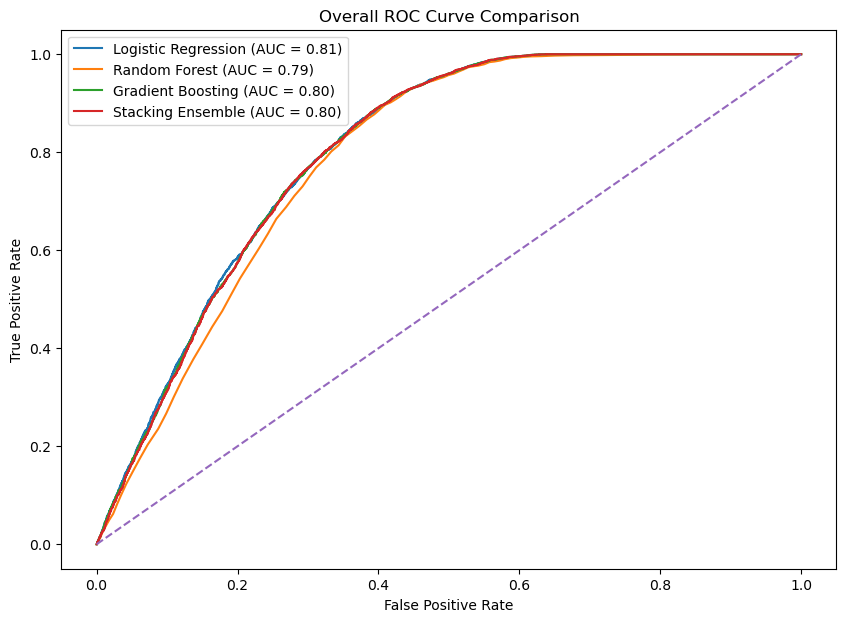

In [43]:
# ROC CURVE

plt.figure(figsize=(10,7))

plt.plot(fpr_log, tpr_log,
         label=f'Logistic Regression (AUC = {auc_log:.2f})')

plt.plot(fpr_rf, tpr_rf,
         label=f'Random Forest (AUC = {auc_rf:.2f})')

plt.plot(fpr_gb, tpr_gb,
         label=f'Gradient Boosting (AUC = {auc_gb:.2f})')

plt.plot(fpr_stack, tpr_stack,
         label=f'Stacking Ensemble (AUC = {auc_stack:.2f})')

# Reference line
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Overall ROC Curve Comparison")

plt.legend()

plt.show()

In [44]:
# FEATURE IMPORTANCE

importances = rf_model.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance:\n")

display(importance_df)



Feature Importance:



,Feature,Importance
2,Inventory_Level,0.373410
4,Price,0.108348
7,Competitor_Pricing,0.107966
3,Units_Ordered,0.104113
1,Product_ID,0.075314
0,Store_ID,0.040443
5,Discount,0.039102
6,Holiday_Promotion,0.016516
18,Seasonality_Spring,0.011519
15,Weather_Condition_Rainy,0.011474


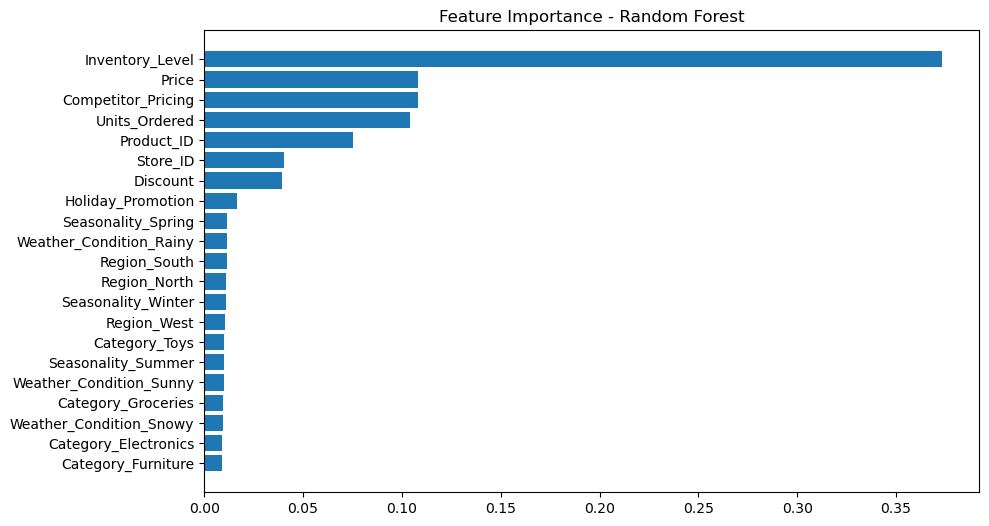

In [45]:
# FEATURE IMPORTANCE VISUALIZATION

plt.figure(figsize=(10,6))

plt.barh(
    importance_df['Feature'],
    importance_df['Importance']
)

plt.title("Feature Importance - Random Forest")

plt.gca().invert_yaxis()

plt.show()



In [46]:
# The stacking ensemble combines predictions from Random Forest and Gradient Boosting classifiers using Logistic Regression as the meta-learner to improve overall predictive performance.
